In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (12,6)

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [3]:
nav.info()


<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


# NAV Trend Analysis

This section analyses the daily NAV movement of mutual fund schemes from 2022 to 2026.

In [4]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [6]:
print("Start Date:", nav["date"].min())
print("End Date:", nav["date"].max())

Start Date: 2022-01-03 00:00:00
End Date: 2026-05-29 00:00:00


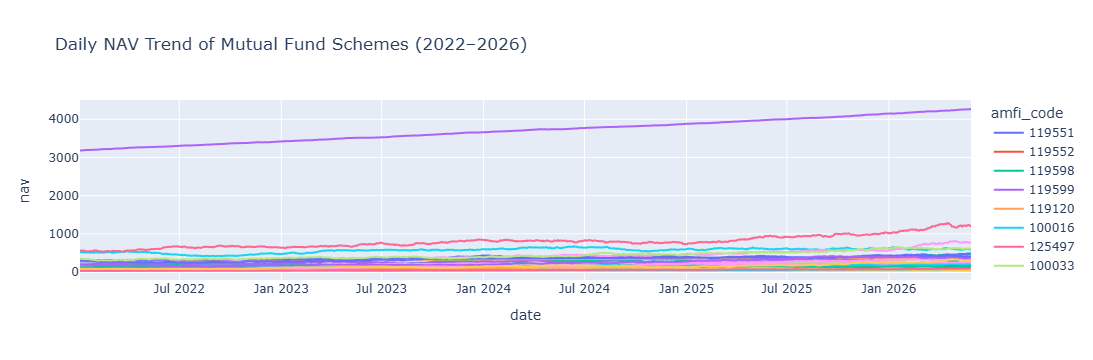

In [7]:
fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

fig.show()

In [8]:
fig.write_html("../reports/nav_trend.html")

## Insight 1

The NAV trend chart shows how mutual fund NAVs changed over time. Interactive visualization helps compare the performance of multiple schemes and identify periods of sustained growth or decline.


In [9]:
import pandas as pd

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

In [10]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


In [11]:
aum.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            90 non-null     str    
 1   fund_house      90 non-null     str    
 2   aum_lakh_crore  90 non-null     float64
 3   aum_crore       90 non-null     int64  
 4   num_schemes     90 non-null     int64  
dtypes: float64(1), int64(2), str(2)
memory usage: 3.6 KB


In [12]:
print(aum["date"].unique())

<StringArray>
['2022-03-31', '2022-09-30', '2023-03-31', '2023-09-30', '2024-03-31',
 '2024-09-30', '2024-12-31', '2025-03-31', '2025-12-31']
Length: 9, dtype: str


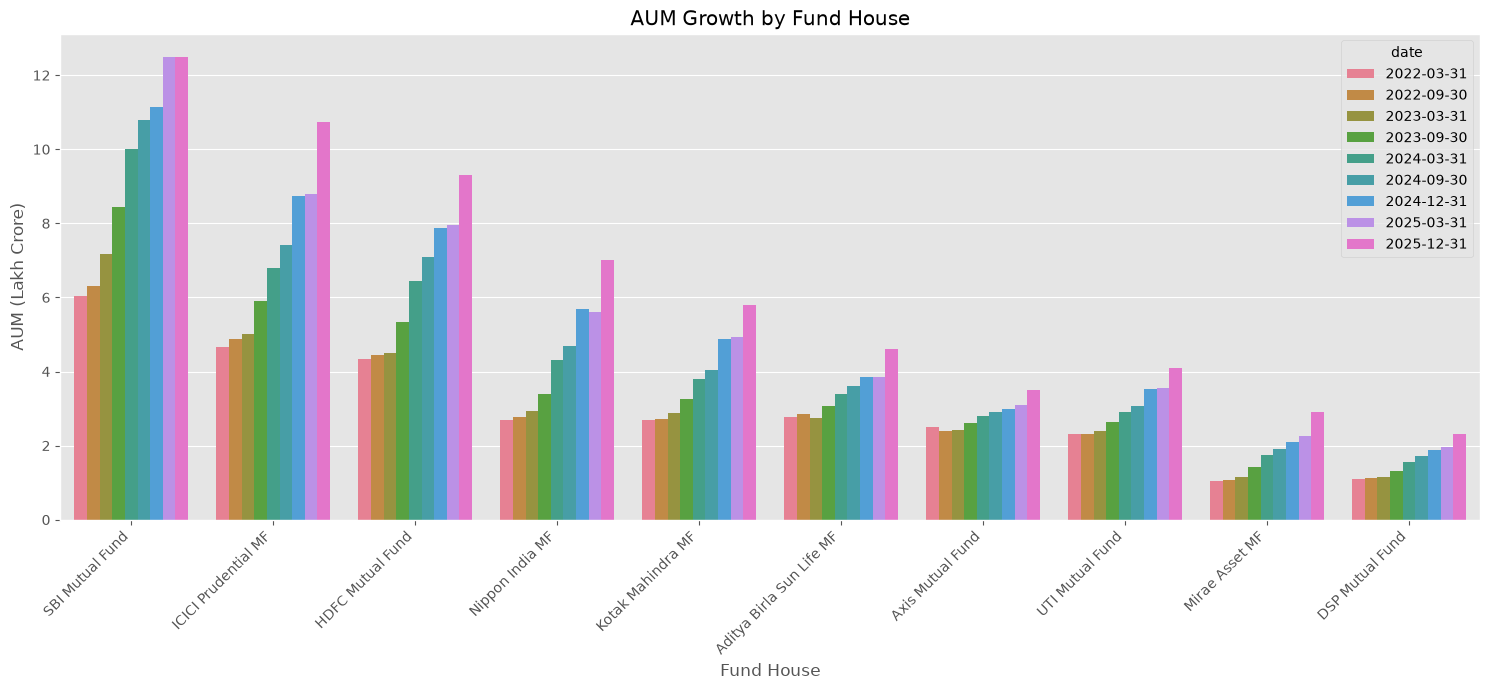

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="date"
)

plt.xticks(rotation=45, ha="right")
plt.title("AUM Growth by Fund House")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")
plt.tight_layout()

plt.show()

## Insight 2

The chart compares the Assets Under Management (AUM) of different fund houses over time. Larger AUM values indicate a stronger market presence and greater investor confidence.

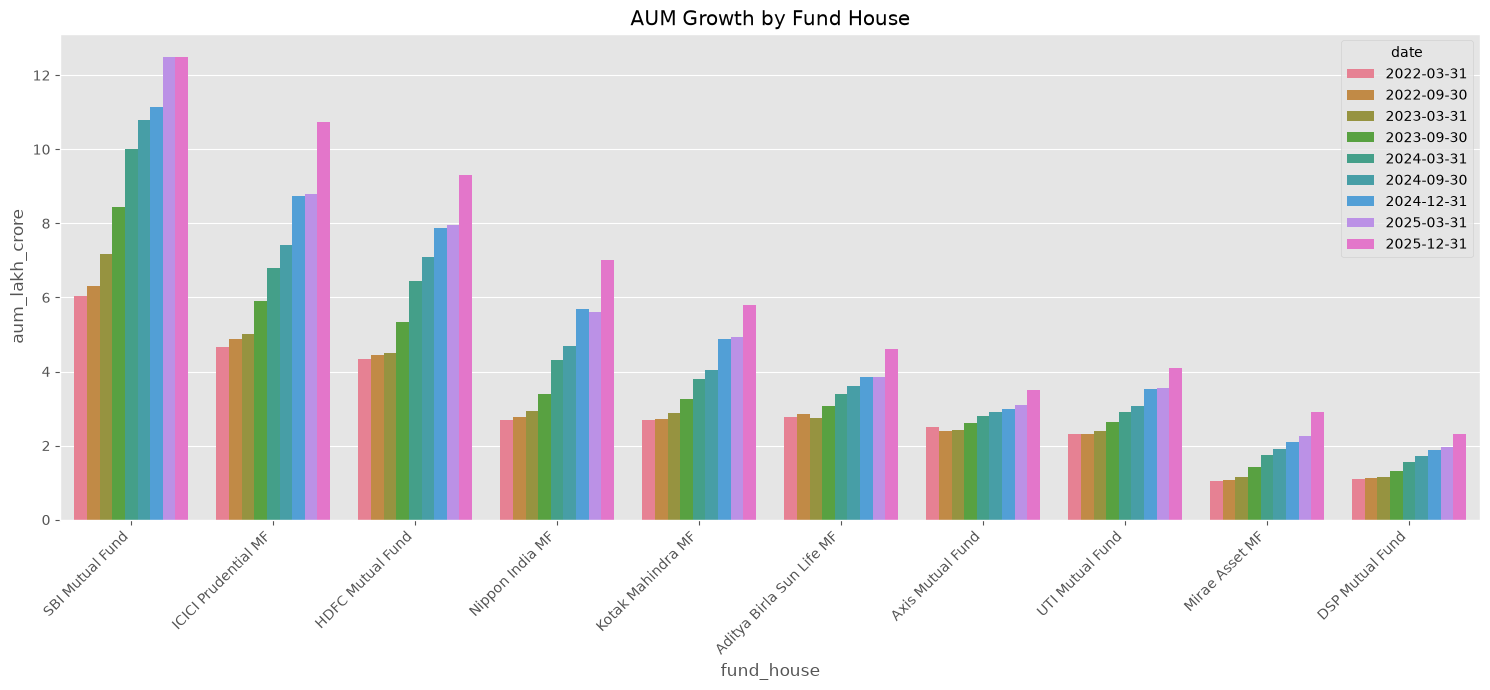

In [14]:
plt.figure(figsize=(15,7))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_lakh_crore",
    hue="date"
)

plt.xticks(rotation=45, ha="right")
plt.title("AUM Growth by Fund House")
plt.tight_layout()

plt.savefig("../reports/aum_growth.png", dpi=300)

plt.show()

# Monthly SIP Inflow Trend

This section analyses monthly SIP inflows to identify growth trends and peak investment periods.

In [15]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [16]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

# Monthly SIP Inflow Trend

This section analyses the monthly SIP inflow trend from 2022–2025 to understand investor participation and growth.

In [17]:
sip["month"] = pd.to_datetime(sip["month"])

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01-01,11517,4.91,9.10,4.80,NaN
1,2022-02-01,11438,4.93,8.20,4.85,NaN
2,2022-03-01,12328,5.09,10.50,5.01,NaN
3,2022-04-01,11863,5.48,9.52,5.12,NaN
4,2022-05-01,12286,5.55,8.10,5.15,NaN


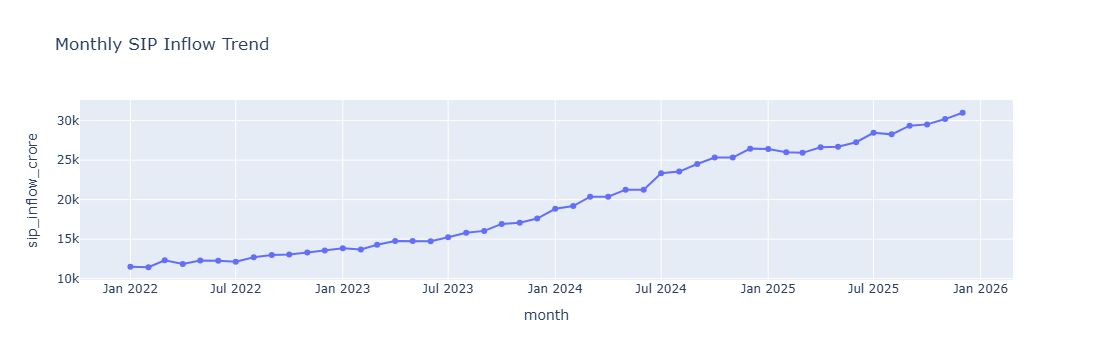

In [18]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend",
    markers=True
)

fig.show()

In [19]:
highest = sip.loc[sip["sip_inflow_crore"].idxmax()]

print(highest)

month                        2025-12-01 00:00:00
sip_inflow_crore                           31002
active_sip_accounts_crore                   9.35
new_sip_accounts_lakh                        9.8
sip_aum_lakh_crore                          15.9
yoy_growth_pct                             17.17
Name: 47, dtype: object


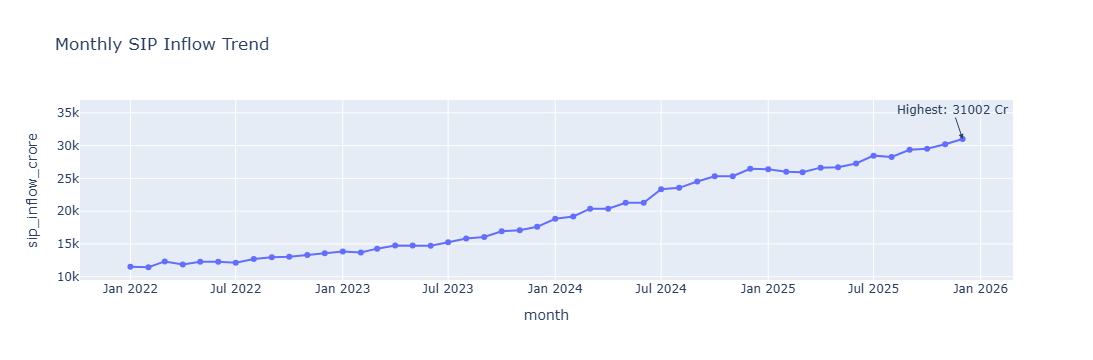

In [20]:
fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflow Trend",
    markers=True
)

fig.add_annotation(
    x=highest["month"],
    y=highest["sip_inflow_crore"],
    text=f'Highest: {highest["sip_inflow_crore"]:.0f} Cr',
    showarrow=True,
    arrowhead=2
)

fig.show()

In [21]:
fig.write_html("../reports/sip_inflow_trend.html")

## Insight 3

Monthly SIP inflows show the trend in systematic investments over time. The highest SIP inflow recorded in the dataset reflects strong investor participation during that period.

# Category Inflow Heatmap

This section visualizes the monthly inflows across mutual fund categories using a heatmap.

In [22]:
category = pd.read_csv("../data/raw/05_category_inflows.csv")

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [23]:
category.columns

Index(['month', 'category', 'net_inflow_crore'], dtype='str')

# Category Inflow Heatmap

This section visualizes monthly net inflows across different mutual fund categories.

In [24]:
category["month"] = pd.to_datetime(category["month"])

category.head()

,month,category,net_inflow_crore
0,2024-04-01,Large Cap,2413.0
1,2024-04-01,Mid Cap,3897.0
2,2024-04-01,Small Cap,3533.0
3,2024-04-01,Flexi Cap,4947.0
4,2024-04-01,Large & Mid Cap,4214.0


In [25]:
heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data

month,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


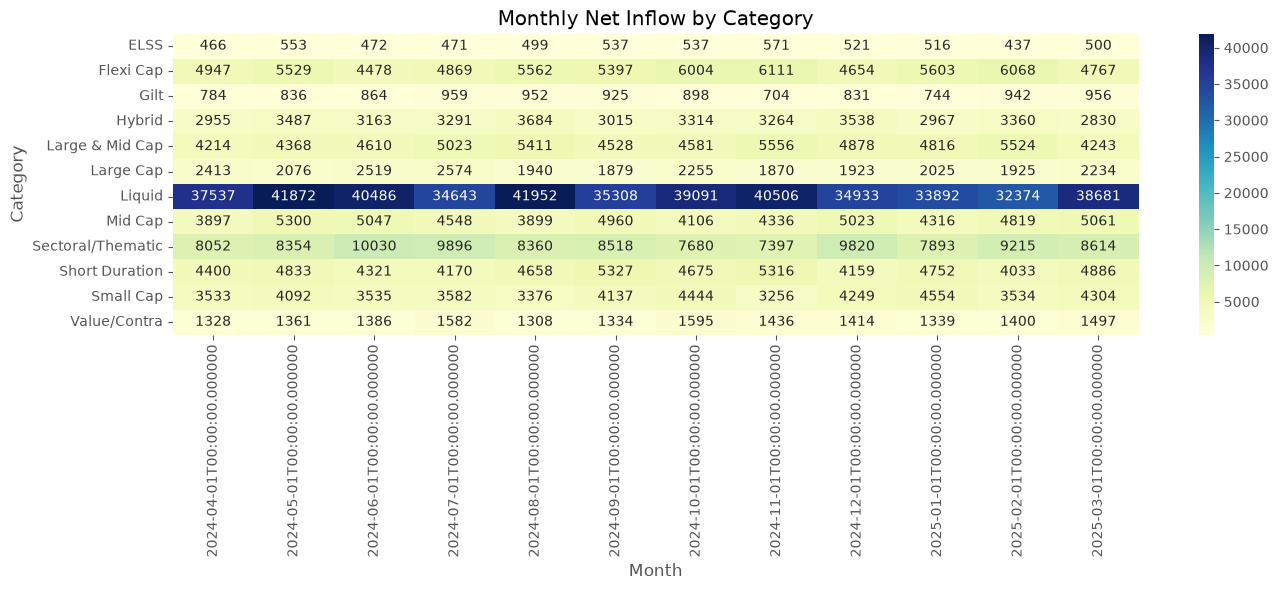

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Monthly Net Inflow by Category")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

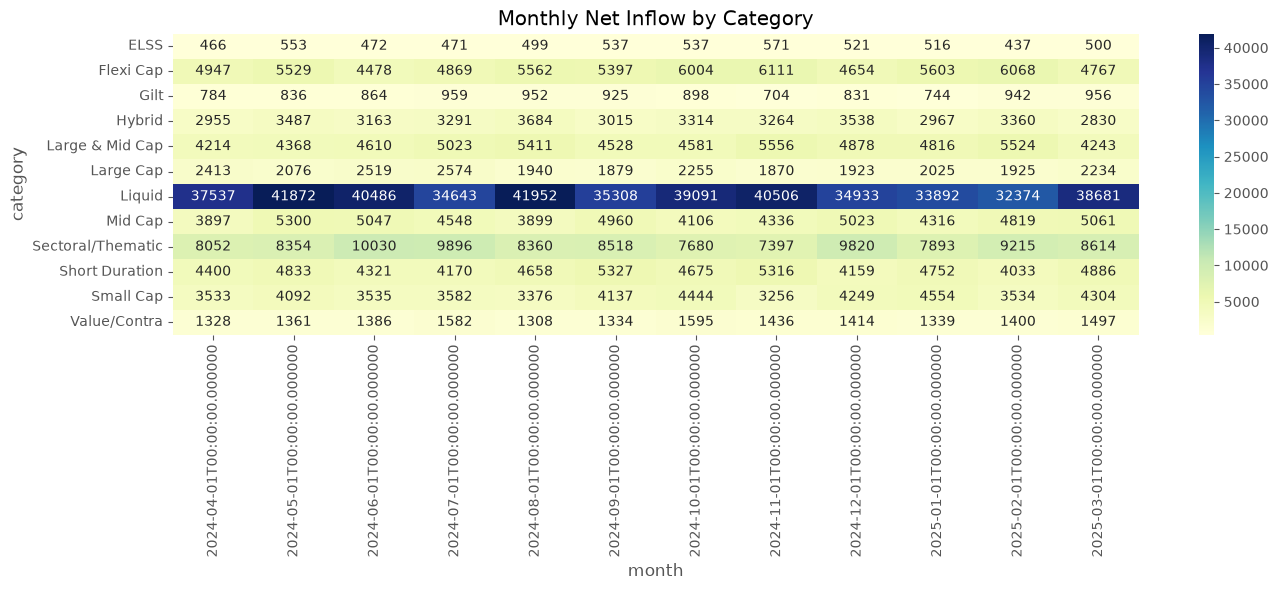

In [27]:
plt.figure(figsize=(14,6))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=True,
    fmt=".0f"
)

plt.title("Monthly Net Inflow by Category")

plt.tight_layout()

plt.savefig("../reports/category_heatmap.png", dpi=300)

plt.show()

## Insight 4

The heatmap highlights monthly net inflows across fund categories. Darker colours indicate months with stronger investor inflows, making it easy to identify seasonal trends and category preferences.

In [28]:
investor = pd.read_csv("../data/raw/08_investor_transactions.csv")

investor.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [29]:
print(investor.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


# Investor Age Group Distribution

This chart shows the distribution of investors across different age groups.

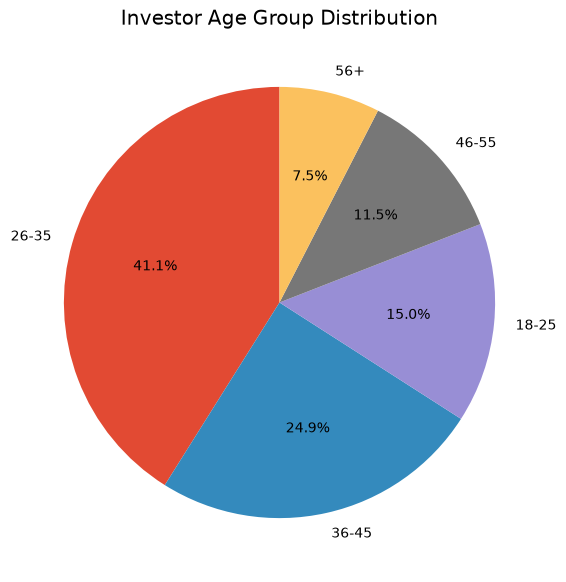

In [30]:
import matplotlib.pyplot as plt

age_counts = investor["age_group"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Age Group Distribution")

plt.show()

## SIP Amount Distribution by Age Group

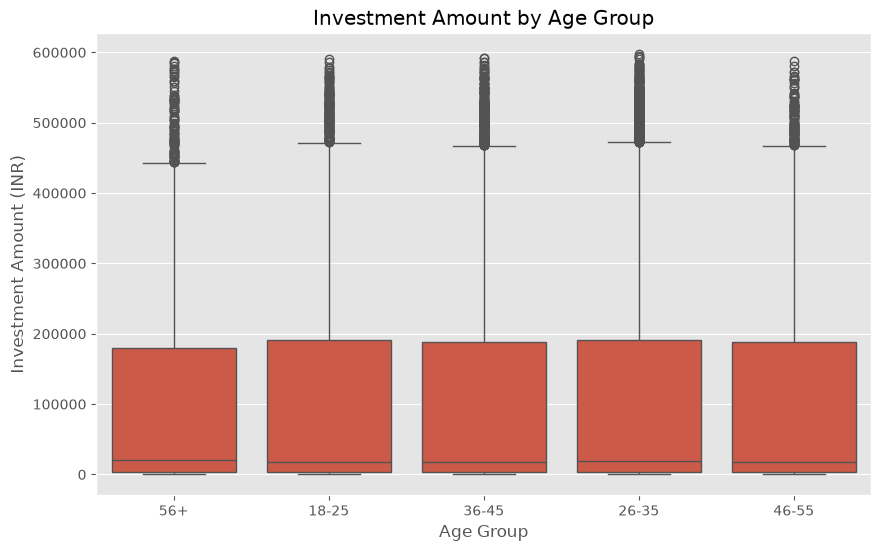

In [31]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.boxplot(
    data=investor,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.show()

## Gender Distribution of Investors

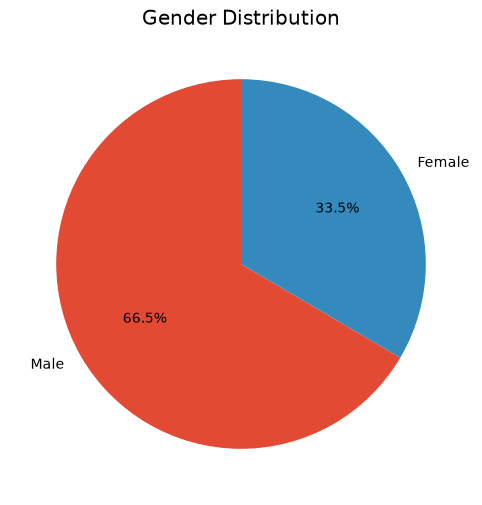

In [32]:
gender = investor["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

## Investment Amount by State

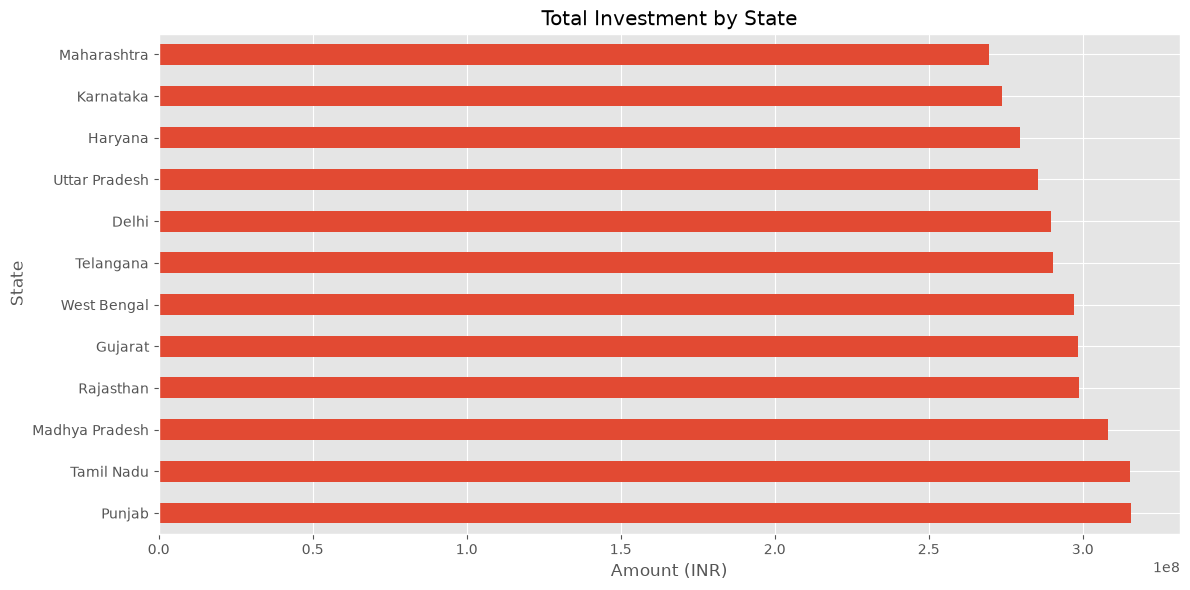

In [33]:
state_data = (
    investor.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

state_data.plot(kind="barh")

plt.title("Total Investment by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

## T30 vs B30 City Tier

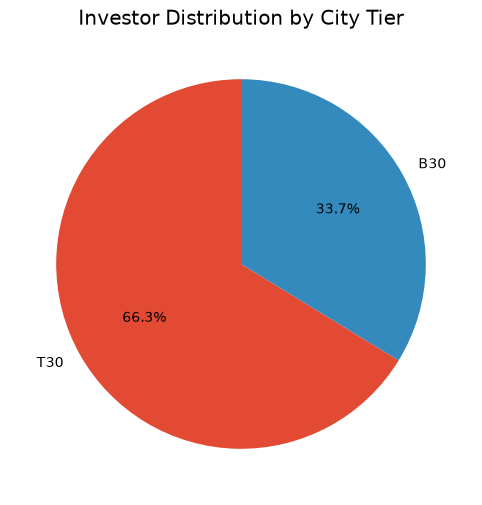

In [34]:
tier = investor["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Investor Distribution by City Tier")

plt.show()

## Insight 5

Most investors belong to a limited number of age groups, indicating stronger participation from specific demographics.

## Insight 6

Investment amounts vary across age groups, suggesting differences in investment capacity and risk appetite.

## Insight 7

The gender distribution provides insight into investor participation and market diversity.

## Insight 8

Some states contribute significantly more investment than others, indicating regional concentration.

## Insight 9

The comparison between T30 and B30 cities highlights the geographic spread of mutual fund investments.

# Folio Count Growth

This section analyses the growth in mutual fund folio counts over time.

In [35]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [36]:
folio.columns

Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='str')

# NAV Return Correlation Matrix

This section computes the correlation between daily NAV returns of selected mutual fund schemes.

In [37]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [38]:
nav_pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339,...,49.9131,3180.6318,560.1443,117.5969,70.2514,84.0757,28.8620,348.7159,78.4622,81.6814
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033,...,50.8195,3181.4042,560.7052,117.0077,71.6085,85.4096,29.1038,345.7198,78.5000,80.8239
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564,...,50.1942,3182.8754,563.0884,116.4011,71.3264,84.7554,29.5489,343.4795,79.1806,80.6143
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088,...,50.6213,3184.9450,561.0675,116.0861,72.1746,84.3563,29.5744,342.1680,78.0831,79.9386
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585,...,49.9391,3185.5042,559.5420,114.6164,72.2118,84.9469,29.6091,340.7757,78.4202,80.8723


In [39]:
returns = nav_pivot.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680


In [40]:
corr = returns.corr()

corr.head()


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
amfi_code,,,,,,,,,,,,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781,...,0.023033,-0.006097,0.047139,-0.016089,0.002264,0.004676,0.045290,0.035192,-0.010164,0.028672
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166,...,-0.003257,0.022290,0.011326,-0.025505,0.010897,-0.017995,-0.010431,-0.002087,-0.000398,0.020955
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318,...,0.023025,0.010619,-0.025137,-0.011916,-0.000268,0.038488,-0.006109,-0.049355,0.018986,-0.060504
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432,...,-0.008136,0.009300,-0.020000,-0.009070,-0.021644,-0.004259,0.023468,0.021622,-0.000607,-0.004785
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384,...,0.058576,-0.075322,-0.046542,0.022493,0.015678,-0.050823,-0.002198,0.020669,0.011435,-0.006471


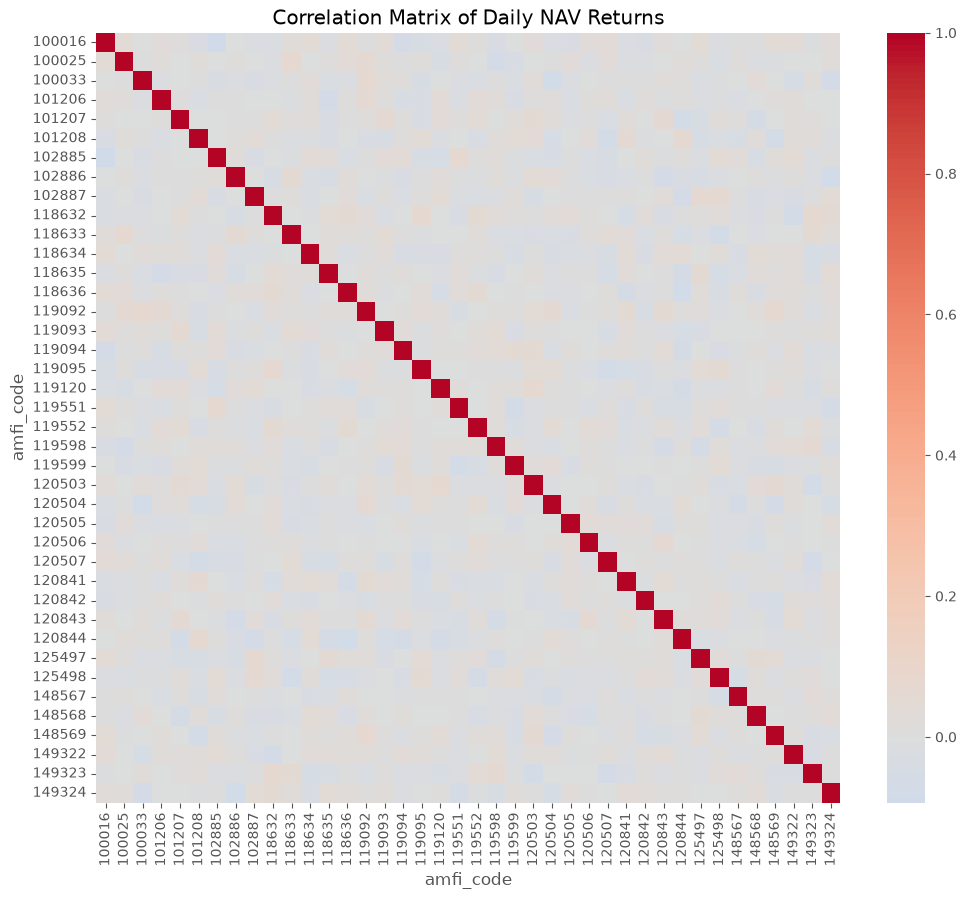

In [41]:
plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Daily NAV Returns")

plt.show()

## Insight 10

The correlation matrix shows how similarly different mutual fund schemes move over time. Higher positive correlations indicate similar market behaviour, while lower correlations suggest diversification opportunities.

In [42]:
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

portfolio.head()


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [43]:
portfolio.columns


Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [44]:
print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


# Sector Allocation Analysis

This chart shows the overall portfolio allocation across different sectors.

In [45]:
sector_data = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_data

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

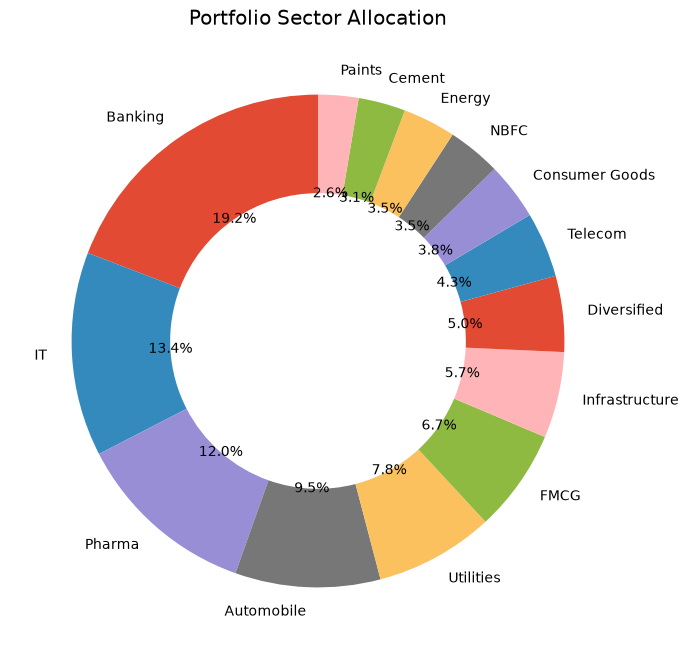

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    sector_data,
    labels=sector_data.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.4}
)

plt.title("Portfolio Sector Allocation")

plt.show()

## Insight 11

The sector allocation chart shows the distribution of portfolio investments across different sectors. Higher allocation to specific sectors indicates greater portfolio concentration, while diversification across sectors helps reduce investment risk.

# Key EDA Findings

## 1. NAV Trend
The daily NAV analysis shows the performance of mutual fund schemes over time, with noticeable changes across different market periods.

## 2. Assets Under Management (AUM)
The AUM comparison highlights the relative size of fund houses and their market presence.

## 3. SIP Inflow Trend
Monthly SIP inflows indicate increasing investor participation and long-term investment interest.

## 4. Category-wise Inflows
Different mutual fund categories attracted varying levels of investor inflows across different months.

## 5. Age Group Distribution
Most investors belong to a few dominant age groups, indicating stronger participation from specific demographics.

## 6. Investment Amount Analysis
Investment amounts vary across age groups, showing different investment capacities among investors.

## 7. Gender Distribution
The dataset provides insights into the participation of different genders in mutual fund investments.

## 8. Geographic Analysis
Investment activity differs across states and city tiers, showing regional investment patterns.

## 9. Folio Growth
Industry folio counts increased steadily, reflecting continuous growth in mutual fund adoption.

## 10. Portfolio Diversification
Sector allocation demonstrates how investments are distributed across industries, helping evaluate portfolio diversification.